# Signal construction and backtest

Estimate a Kalman-filtered hedge ratio for the strongest pair from the cointegration scan, build the z-score spread signal, and run a cost-adjusted backtest. This notebook develops and evaluates everything **in-sample only** (the train portion of the walk-forward split) - the held-out test window is left untouched until notebook 05.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.utils.config import load_config
from src.signals.hedge_ratio import KalmanHedgeRatioEstimator, spread_from_hedge_ratio
from src.backtest.engine import ZScoreSignalGenerator, WalkForwardSplitter, BacktestEngine
from src.backtest.costs import CostModel
from src.evaluation.metrics import PerformanceEvaluator

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

config = load_config("../config/config.yaml")
aligned = pl.read_parquet("../data/processed/aligned.parquet")

with open("../outputs/tables/selected_pair.txt") as f:
    asset_a, asset_b = f.read().strip().split(",")
print(f"Selected pair: {asset_a}-{asset_b}")

Selected pair: BCH-ADA


## Walk-forward split

The train window calibrates everything (hedge ratio, thresholds); the test window is not touched until notebook 05. `out_of_sample_fraction` from config sets the split point.

In [2]:
price_a_full = aligned[f"{asset_a}_price"].to_numpy()
price_b_full = aligned[f"{asset_b}_price"].to_numpy()
timestamps_full = aligned["timestamp"].to_numpy()

train_slice, test_slice = WalkForwardSplitter(config["backtest"]["out_of_sample_fraction"]).split(len(price_a_full))
print(f"train: {timestamps_full[train_slice][0]} -> {timestamps_full[train_slice][-1]} ({train_slice.stop - train_slice.start} bars)")
print(f"test:  {timestamps_full[test_slice][0]} -> {timestamps_full[test_slice][-1]} ({test_slice.stop - test_slice.start} bars)")

price_a = price_a_full[train_slice]
price_b = price_b_full[train_slice]
timestamps = timestamps_full[train_slice]

train: 2021-07-08T23:18:20.000000 -> 2024-08-27T20:18:20.000000 (27502 bars)
test:  2024-08-27T21:18:20.000000 -> 2025-12-31T23:18:20.000000 (11787 bars)


## Kalman-filtered hedge ratio (train only)

A static OLS hedge ratio is fit once and goes stale; the cointegration scan already showed these relationships aren't stable over time, so the hedge ratio is re-estimated every bar via a Kalman filter instead (state = [hedge ratio, intercept], seeded from an OLS fit via `sklearn.linear_model.LinearRegression` on the first bars of the train window).

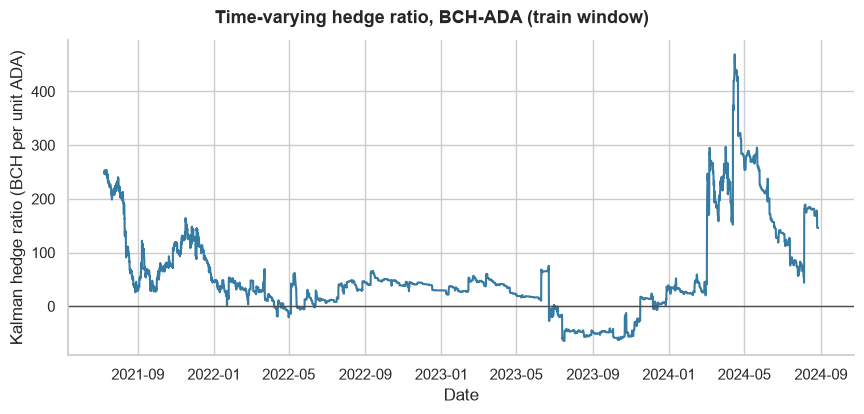

In [3]:
hr_cfg = config["hedge_ratio"]
hedge_estimator = KalmanHedgeRatioEstimator(delta=hr_cfg["delta"], observation_covariance=hr_cfg["observation_covariance"])
hedge_ratio = hedge_estimator.hedge_ratio_only(price_a, price_b)
spread = spread_from_hedge_ratio(price_a, price_b, hedge_ratio)

hedge_df = pd.DataFrame({"timestamp": pd.to_datetime(timestamps), "hedge_ratio": hedge_ratio})
g = sns.relplot(
    data=hedge_df, x="timestamp", y="hedge_ratio", kind="line", height=4, aspect=2.2,
    color=sns.color_palette("mako", 1)[0],
)
g.ax.axhline(0, color="0.3", linewidth=1)
g.set_axis_labels("Date", f"Kalman hedge ratio ({asset_a} per unit {asset_b})")
g.figure.suptitle(f"Time-varying hedge ratio, {asset_a}-{asset_b} (train window)", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/hedge_ratio_train.png", dpi=150)

## Cointegrating relationship, visualised

Scatter of the two price series, coloured by time, over the train window - a genuine cointegrating relationship should trace out a stable-ish band rather than drifting into visibly separate regimes.

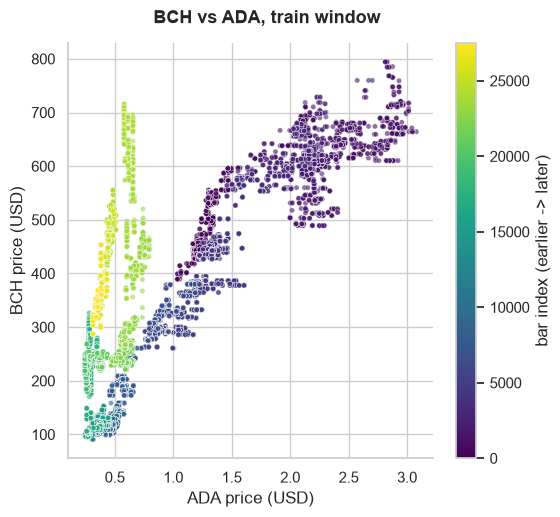

In [4]:
scatter_df = pd.DataFrame({"time_idx": np.arange(len(price_a)), asset_a: price_a, asset_b: price_b})
g = sns.relplot(
    data=scatter_df, x=asset_b, y=asset_a, hue="time_idx", kind="scatter",
    palette="viridis", height=5, aspect=1.1, s=14, alpha=0.6, legend=False,
)
norm = plt.Normalize(scatter_df["time_idx"].min(), scatter_df["time_idx"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.figure.colorbar(sm, ax=g.ax, label="bar index (earlier -> later)")
g.set_axis_labels(f"{asset_b} price (USD)", f"{asset_a} price (USD)")
g.figure.suptitle(f"{asset_a} vs {asset_b}, train window", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/price_relationship_scatter.png", dpi=150)

## Z-score signal

Rolling z-score of the spread (`signal.lookback` bars), entering at `|z| >= entry_z` and holding until `|z| <= exit_z` (hysteresis, to avoid churning around the entry threshold).

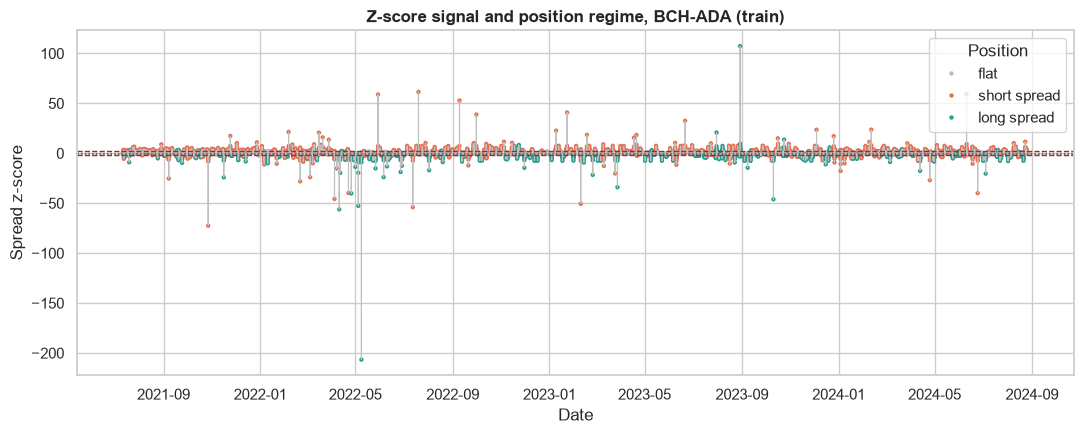

Time in position: 61.9%


In [5]:
sig_cfg = config["signal"]
signal_gen = ZScoreSignalGenerator(lookback=sig_cfg["lookback"], entry_z=sig_cfg["entry_z"], exit_z=sig_cfg["exit_z"])
zscore = signal_gen.zscore(spread)
positions = signal_gen.positions(spread)

regime = np.where(positions > 0, "long spread", np.where(positions < 0, "short spread", "flat"))
regime_palette = {"long spread": "#2a9d8f", "short spread": "#e76f51", "flat": "#bdbdbd"}

spread_df = pd.DataFrame({"timestamp": pd.to_datetime(timestamps), "zscore": zscore, "regime": regime})
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=spread_df, x="timestamp", y="zscore", color="0.75", linewidth=0.8, ax=ax)
sns.scatterplot(data=spread_df, x="timestamp", y="zscore", hue="regime", palette=regime_palette,
                 s=10, linewidth=0, ax=ax)
ax.axhline(sig_cfg["entry_z"], color="firebrick", linestyle="--", linewidth=1)
ax.axhline(-sig_cfg["entry_z"], color="firebrick", linestyle="--", linewidth=1)
ax.axhline(sig_cfg["exit_z"], color="0.4", linestyle=":", linewidth=1)
ax.axhline(-sig_cfg["exit_z"], color="0.4", linestyle=":", linewidth=1)
ax.set_ylabel("Spread z-score")
ax.set_xlabel("Date")
ax.set_title(f"Z-score signal and position regime, {asset_a}-{asset_b} (train)", fontsize=12, fontweight="bold")
ax.legend(title="Position", loc="upper right", frameon=True)
fig.tight_layout()
fig.savefig("../outputs/figures/zscore_signal_train.png", dpi=150)
plt.show()

print(f"Time in position: {np.mean(positions != 0):.1%}")

## Cost-adjusted backtest (in-sample)

`BacktestEngine` normalises P&L by the gross notional of a 1-unit-A / hedge_ratio-unit-B spread position to get genuine percentage returns, lags both the position and the hedge ratio by one bar (no look-ahead), and deducts `backtest.cost_bps` per side on every entry/exit/flip.

In [6]:
cost_model = CostModel(cost_bps=config["backtest"]["cost_bps"])
engine = BacktestEngine(cost_model)
result = engine.run(positions, price_a, price_b, hedge_ratio)

periods_per_year = int(pd.Timedelta("365D") / pd.Timedelta(config["alignment"]["grid_freq"]))
evaluator = PerformanceEvaluator(periods_per_year=periods_per_year)
summary = evaluator.summary(result["net_returns"], result["equity_curve"])
summary["asset_a"], summary["asset_b"], summary["phase"] = asset_a, asset_b, "in_sample"
pd.DataFrame([summary]).to_csv("../outputs/tables/backtest_in_sample_summary.csv", index=False)
summary

{'sharpe': 0.22373820540719228,
 'sharpe_se': 0.5643785957861819,
 'max_drawdown': -1.466144129614694,
 'hit_rate': 0.37433671008200675,
 'total_return': -0.19407704303584994,
 'n_periods': 27502,
 'asset_a': 'BCH',
 'asset_b': 'ADA',
 'phase': 'in_sample'}

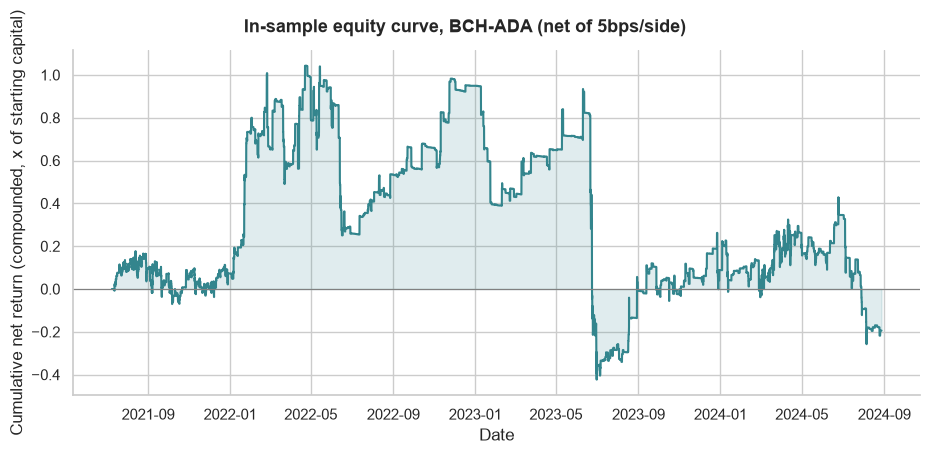

In [7]:
equity_df = pd.DataFrame({"timestamp": pd.to_datetime(timestamps), "equity": result["equity_curve"]})
g = sns.relplot(
    data=equity_df, x="timestamp", y="equity", kind="line", height=4.3, aspect=2.2,
    color=sns.color_palette("crest", 1)[0],
)
g.ax.fill_between(equity_df["timestamp"], 0, equity_df["equity"],
                   color=sns.color_palette("crest", 1)[0], alpha=0.15)
g.ax.axhline(0, color="0.5", linewidth=0.8)
g.set_axis_labels("Date", "Cumulative net return (compounded, x of starting capital)")
g.figure.suptitle(f"In-sample equity curve, {asset_a}-{asset_b} (net of {config['backtest']['cost_bps']}bps/side)",
                   fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/equity_curve_in_sample.png", dpi=150)

## Selection-bias check: how do the other 5 candidate pairs backtest?

The pair above was chosen by the cointegration scan (notebook 03), independent of backtest performance - but reporting only the winner's Sharpe still invites the reader to read it as unconditional. The cheapest honest partial fix for that (short of a full Probability-of-Backtest-Overfitting/Deflated-Sharpe correction) is to just show what the same pipeline, run identically on every candidate pair, actually produces - so the winner's number can be read in context rather than in isolation.

In [8]:
all_pairs_rows = []
for a, b in [tuple(p) for p in config["pairs"]]:
    pa = aligned[f"{a}_price"].to_numpy()[train_slice]
    pb = aligned[f"{b}_price"].to_numpy()[train_slice]
    hr = hedge_estimator.hedge_ratio_only(pa, pb)
    sp = spread_from_hedge_ratio(pa, pb, hr)
    pos = signal_gen.positions(sp)
    res = engine.run(pos, pa, pb, hr)
    s = evaluator.summary(res["net_returns"], res["equity_curve"])
    s["pair"] = f"{a}-{b}"
    all_pairs_rows.append(s)

all_pairs_df = pd.DataFrame(all_pairs_rows)[["pair", "sharpe", "sharpe_se", "max_drawdown", "hit_rate", "total_return"]]
all_pairs_df = all_pairs_df.sort_values("sharpe", ascending=False).reset_index(drop=True)
all_pairs_df.to_csv("../outputs/tables/all_pairs_in_sample_backtest.csv", index=False)
all_pairs_df

,pair,sharpe,sharpe_se,max_drawdown,hit_rate,total_return
0,SOL-ADA,1.309042,0.564405,-5.928353,0.375065,8.463724
1,BCH-ADA,0.223738,0.564379,-1.466144,0.374337,-0.194077
2,BCH-XRP,-0.136263,0.564378,-2.410723,0.321945,-0.541071
3,SOL-XRP,-0.243307,0.564379,-0.928475,0.305916,-0.799365
4,SOL-BCH,-0.428860,0.564381,-0.929162,0.418257,-0.744555
5,ADA-XRP,-0.581559,0.564383,-1.432144,0.309966,-0.807934


## Takeaways

- **The selected pair's in-sample backtest is not profitable** - Sharpe and total return above are read directly from the summary table, not asserted here, and should be checked against it rather than assumed. This is a real, if unflattering, result: the cointegration-scan selection rule (highest fraction of significant random windows, fixed *before* looking at backtest performance) does not guarantee - or even reliably produce - a profitable pair, and this run is a concrete demonstration of that rather than a hypothetical caveat.
- **The all-six-pairs table above makes this legible rather than hidden**: at least one other candidate pair backtests meaningfully better in-sample than the selected one. Precisely because the selection rule was pre-registered on cointegration stability alone, swapping to whichever pair happens to backtest best *now* would reintroduce the exact performance-chasing selection bias the rule exists to avoid - so the original selection is carried forward into notebook 05's out-of-sample test unchanged, even though it is the less flattering choice.
- The `sharpe_se` column is the asymptotic standard error of the annualised Sharpe (`sqrt((1+0.5*SR^2)/N)`, assuming IID returns - which held positions violate, so treat this as an optimistic lower bound, not a tight interval). The SE is large relative to every pair's point estimate in the table above, including the selected one - none of these Sharpe ratios should be read as precise to two decimal places.
- The equity curve's drawdown and the fraction of time spent in a position are both worth reading alongside the Sharpe ratio - a high Sharpe with very low position-holding time is a different (and more fragile) animal than one built on sustained exposure.
- Notebook 05 takes this exact, unmodified calibration - same hedge-ratio filter (warm-started from train only), same z-score thresholds, same cost assumption - and applies it unchanged to the held-out test window.